This notebook reproduces the example from scDesign3 package: [Simulate datasets with multiple lineages](https://songdongyuan1994.github.io/scDesign3/docs/articles/scDesign3-multipleLineages-vignette.html)

In [ ]:
from scdesigner.datasets import marrow

example_sce = marrow()
example_sce = example_sce[:, :100].to_memory()

In [2]:
example_sce.obs[["pseudotime1", "pseudotime2", "l1", "l2"]]

,pseudotime1,pseudotime2,l1,l2
W31105,0.950862,0.568357,TRUE,TRUE
W31106,9.168276,-1.000000,TRUE,FALSE
W31107,-1.000000,7.981990,FALSE,TRUE
W31108,11.394132,-1.000000,TRUE,FALSE
W31109,-1.000000,8.080133,FALSE,TRUE
...,...,...,...,...
W39164,-1.000000,10.675819,FALSE,TRUE
W39165,8.708608,-1.000000,TRUE,FALSE
W39166,0.136108,0.117735,TRUE,TRUE
W39167,11.376395,-1.000000,TRUE,FALSE


See page 138 of the [mgcv manual](https://cran.r-project.org/web/packages/mgcv/mgcv.pdf) for how scDesign3 can use separate splines for each group using the `by` syntax. We haven't implemented anything like this in our estimation, though it seems possible to prepare a special estimator in this case. As an alternative, we will fit an interaction. This is not exactly the same, but has a similar qualitative interpretation and still seems to result in plausible data.

In [3]:
from scdesigner.simulators import NegBinCopula

formula = "~ pseudotime1 + pseudotime2 + pseudotime1 : l1 + pseudotime2 : l2"
sim = NegBinCopula(mean_formula=formula)
sim.fit(example_sce, max_epochs=100)
simulated = sim.sample()

Epoch 70/100, Loss: 1.5956, Val Loss: 1.6241


Estimating copula correlation: 100%|██████████| 3/3 [00:00<00:00, 11.79it/s]


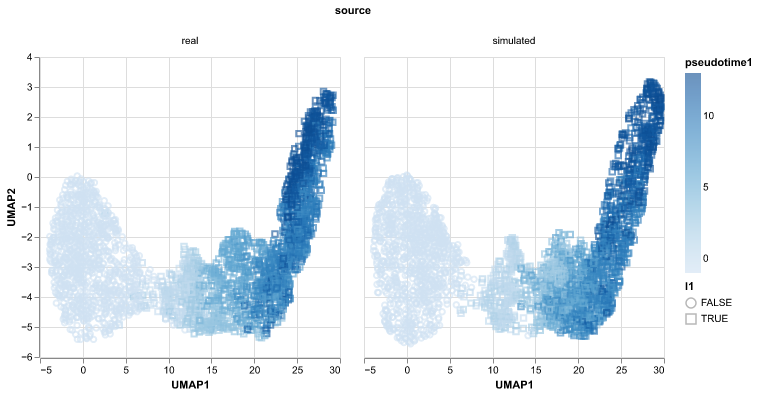

In [4]:
import altair
from scdiagnostics import compare_umap
altair.renderers.enable('png')
altair.data_transformers.enable("vegafusion")

compare_umap(example_sce, simulated, color="pseudotime1", shape="l1")

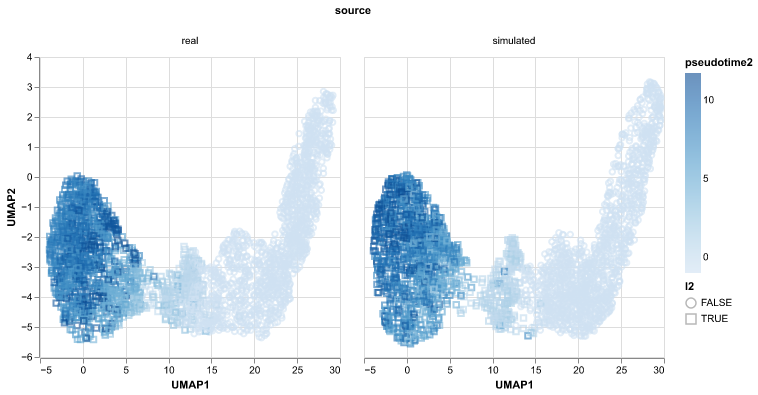

In [5]:
compare_umap(example_sce, simulated, color="pseudotime2", shape="l2")